<a href="https://colab.research.google.com/github/kkm1121/NVIDIA-yolo/blob/20250515/%EC%95%BC%EC%98%B9%EC%9D%B4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving 시험2.png to 시험2.png

0: 640x640 3 cats, 6 dogs, 90.8ms
Speed: 3.2ms preprocess, 90.8ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
감지된 고양이 수: 3


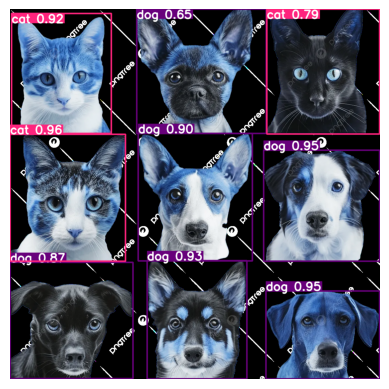

In [3]:
# 1. YOLO 설치
!pip install ultralytics -q

# 2. 필수 라이브러리
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# 3. 이미지 업로드
uploaded = files.upload()
image_path = next(iter(uploaded))

# 4. 이미지 로드
image = cv2.imread(image_path)

# 5. 더 큰 모델 로드 (정확도 향상 위해)
model = YOLO('yolov8x.pt')  # 큰 모델로 변경

# 6. 추론
results = model(image)

# 7. 고양이만 필터링해서 세기
cat_count = 0
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    cls_name = model.names[cls_id]
    if cls_name == 'cat':
        cat_count += 1

print(f"감지된 고양이 수: {cat_count}")

# 8. 결과 시각화
plt.imshow(results[0].plot())
plt.axis('off')
plt.show()